# VLM Test: DINOv2 + Phi-3.5-mini on Oxford Pets

Tests the trained VLM (Stage 2 checkpoint from Modal A10G run).

**Architecture:** DINOv2 ViT-S/14 → 2×2 avg-pool (256→64 tokens) → MLP projector → Phi-3.5-mini-instruct  
**Training:** Stage 1 (3 epochs, projector only) → Stage 2 (10 epochs, projector + LoRA rank=8)  
**Results:** Stage 2 val_loss=0.0292, val_token_acc=98.9%

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image

REPO = Path("..").resolve()
DATA_DIR  = REPO / "experiments" / "datasets" / "oxford_pets"
TRAINED_W = REPO / "experiments/results_modal/vlm_pets/vlm_pets/trained_weights.pt"   # 34 MB
METRICS_S1 = REPO / "experiments/results_modal/vlm_pets/vlm_pets/checkpoints/stage1/lightning_logs/version_0/metrics.csv"
METRICS_S2 = REPO / "experiments/results_modal/vlm_pets/vlm_pets/checkpoints/stage2/lightning_logs/version_0/metrics.csv"
LLM_NAME  = "microsoft/Phi-3.5-mini-instruct"

print("PyTorch:", torch.__version__)
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f"GPU: {gpu.name}  {gpu.total_memory/1e9:.1f} GB")
else:
    print("GPU: not available — using CPU")

PyTorch: 2.5.1+cu121
GPU: NVIDIA GeForce RTX 2060  6.4 GB


## 1. Training Metrics

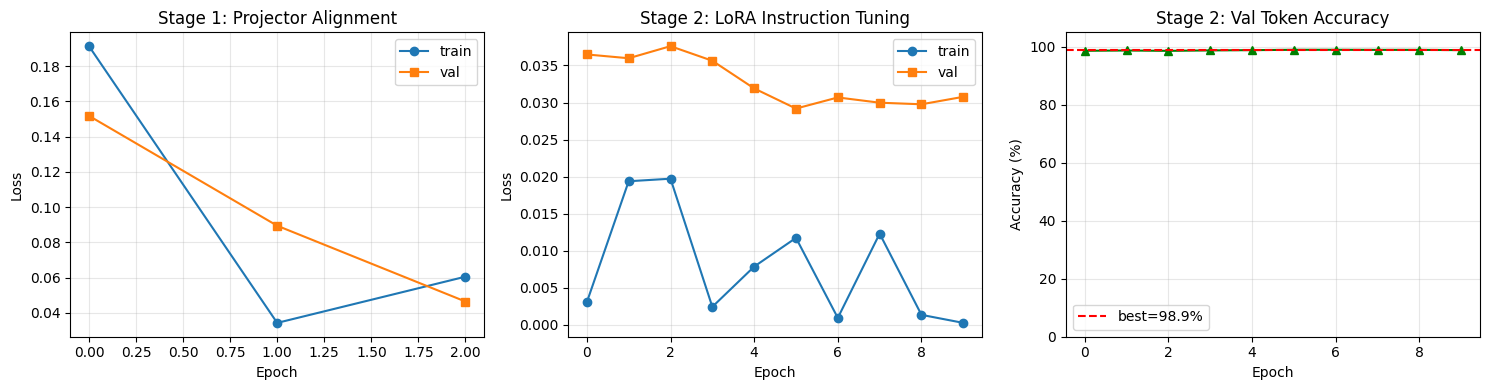

Stage 1  val_loss: 0.046423234045505524
Stage 2  val_loss: 0.029187312349677086
Stage 2  token_acc: 0.9886506199836731
Total time: 126.5 min


In [2]:
def load_metrics(path):
    df = pd.read_csv(path)
    train = df[["epoch", "train_loss"]].dropna().groupby("epoch").last()
    val   = df[["epoch", "val_loss"]].dropna().groupby("epoch").last()
    acc   = df[["epoch", "val_token_acc"]].dropna().groupby("epoch").last() if "val_token_acc" in df else None
    return train, val, acc

tr1, vl1, ac1 = load_metrics(METRICS_S1)
tr2, vl2, ac2 = load_metrics(METRICS_S2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Stage 1 loss
ax = axes[0]
ax.plot(tr1.index, tr1["train_loss"], label="train", marker="o")
ax.plot(vl1.index, vl1["val_loss"],   label="val",   marker="s")
ax.set_title("Stage 1: Projector Alignment")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(True, alpha=0.3)

# Stage 2 loss
ax = axes[1]
ax.plot(tr2.index, tr2["train_loss"], label="train", marker="o")
ax.plot(vl2.index, vl2["val_loss"],   label="val",   marker="s")
ax.set_title("Stage 2: LoRA Instruction Tuning")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(True, alpha=0.3)

# Stage 2 token accuracy
ax = axes[2]
if ac2 is not None:
    ax.plot(ac2.index, ac2["val_token_acc"] * 100, color="green", marker="^")
    ax.axhline(98.9, color="red", linestyle="--", label="best=98.9%")
ax.set_title("Stage 2: Val Token Accuracy")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 105); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

results = json.loads((REPO / "experiments/results_modal/vlm_pets/vlm_pets/results.json").read_text())
print("Stage 1  val_loss:", results["stage1"]["best_val_loss"])
print("Stage 2  val_loss:", results["stage2"]["best_val_loss"])
print("Stage 2  token_acc:", results["stage2"]["val_token_acc"])
print(f"Total time: {results['elapsed_sec']/60:.1f} min")

## 2. Load Model

Loads the Stage 2 checkpoint (projector + LoRA, ~34 MB of trained weights).  
The frozen Phi-3.5-mini weights are loaded fresh from HuggingFace cache (~7.6 GB).  

**Memory:** GPU with ≥10 GB VRAM loads on CUDA (fast); smaller GPUs fall back to CPU (~30 s/query).

In [3]:
from core.encoders import create_encoder
from core.decoders.vlm import VLMDecoder

# ── Build architecture + load LLM from HuggingFace cache ─────────────────────
print("Building encoder...")
encoder = create_encoder("dinov2_vits14", input_size=224)

print(f"Loading {LLM_NAME} (3.8 B params, ~7.6 GB bfloat16)...")
decoder = VLMDecoder(
    encoder,
    llm_name=LLM_NAME,
    freeze_llm=True,
    pool_patches=2,
)
decoder.enable_llm_lora(rank=8)
print(f"  Visual tokens: {decoder.num_visual_tokens}  Projector params: {sum(p.numel() for p in decoder.projector.parameters()):,}")

# ── Load trained weights from compact 34 MB file ─────────────────────────────
print("Loading trained weights (34 MB)...")
trained_sd = torch.load(TRAINED_W, map_location="cpu", weights_only=True)
missing, unexpected = decoder.load_state_dict(trained_sd, strict=False)
print(f"  Loaded {len(trained_sd)} tensors  ({len(missing)} frozen params not in dict, expected)")

# ── Device placement ──────────────────────────────────────────────────────────
# Phi-3.5-mini needs ~8 GB VRAM. Use CUDA only if enough memory; else CPU.
if torch.cuda.is_available() and torch.cuda.get_device_properties(0).total_memory > 10e9:
    encoder_device = "cuda"
    decoder.to("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    encoder_device = "cpu"
    if torch.cuda.is_available():
        print(f"GPU has {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB — need ≥10 GB for bfloat16; using CPU")
    print("CPU mode — ~30 s/query with KV-cache")

decoder.eval()
print("Model ready.")

Building encoder...


Using cache found in C:\Users\dhruv/.cache\torch\hub\facebookresearch_dinov2_main


C:\Users\dhruv/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\dhruv/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\dhruv/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Loading microsoft/Phi-3.5-mini-instruct (3.8 B params, ~7.6 GB bfloat16)...


C:\Users\dhruv\.conda\envs\fft\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


...

Loading weights:  99%|█████████▉| 194/195 [00:00<00:00, 860.18it/s, Materializing param=model.layers.31.self_attn.qkv_proj.weight]

Loading weights: 100%|██████████| 195/195 [00:00<00:00, 860.18it/s, Materializing param=model.norm.weight]                        

Loading weights: 100%|██████████| 195/195 [00:00<00:00, 860.18it/s, Materializing param=model.norm.weight]

Loading weights: 100%|██████████| 195/195 [00:00<00:00, 868.49it/s, Materializing param=model.norm.weight]

  Visual tokens: 64  Projector params: 5,313,024
Loading trained weights (34 MB)...
  Loaded 68 tensors  (370 frozen params not in dict, expected)
GPU has 6.4 GB — need ≥10 GB for bfloat16; using CPU
CPU mode — ~30 s/query with KV-cache
Model ready.


## 3. Dataset Preview

Validation set: 734 images, 3673 total


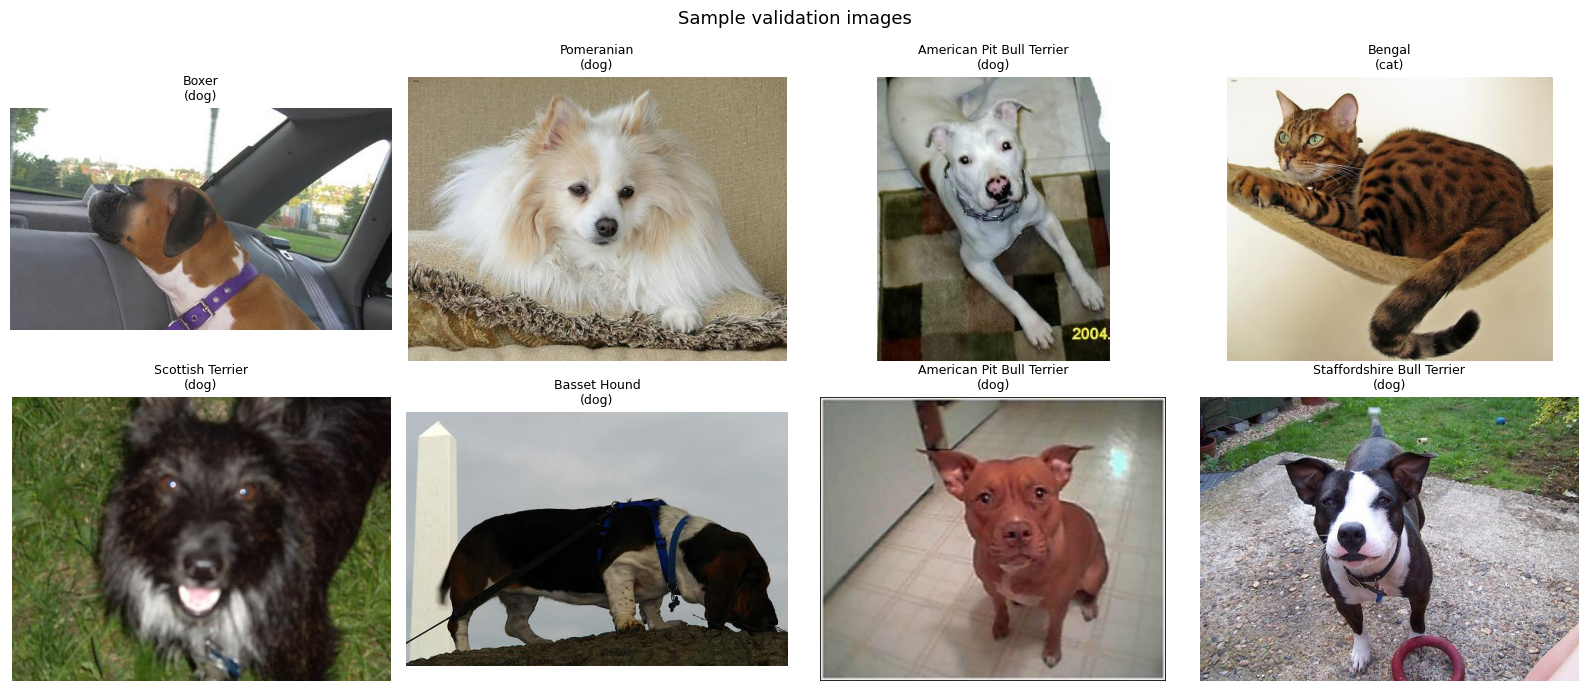

In [4]:
from core.data.vqa_dataset import PetsVQADataset
import numpy as np

dataset = PetsVQADataset(
    annotations_json=DATA_DIR / "annotations.json",
    images_dir=DATA_DIR / "images",
    tokenizer=decoder.tokenizer,
    transform=encoder.get_transform(),
)
_, val_ds = dataset.split()
print(f"Validation set: {len(val_ds)} images, {len(dataset.samples)} total")

# Show a grid of 8 random validation images with breed labels
rng = np.random.RandomState(0)
idxs = rng.choice(len(val_ds), size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, idx in zip(axes.flat, idxs):
    meta = dataset.samples[val_ds.indices[idx]]
    img = Image.open(meta["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"{meta['breed']}\n({meta['species']})", fontsize=9)
    ax.axis("off")
plt.suptitle("Sample validation images", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Teacher-Forced Accuracy Check

Verifies the forward pass and reports token accuracy on a batch.

In [5]:
from torch.utils.data import DataLoader

if encoder_device == "cpu":
    print("Skipping teacher-forced accuracy on CPU — Phi-3.5-mini forward pass is too slow (~10+ min/batch).")
    print("Re-run on a GPU with ≥10 GB VRAM for this section.")
    print(f"\nReported Modal training accuracy: val_token_acc=98.9% (Stage 2)")
else:
    loader = DataLoader(
        val_ds, batch_size=4, shuffle=False,
        collate_fn=PetsVQADataset.collate_fn,
    )
    n_batches = 5

    batch_accs = []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= n_batches:
                break
            features = encoder.forward_features(batch["image"].to(encoder_device))
            out = decoder(
                features,
                input_ids=batch["input_ids"].to(encoder_device),
                attention_mask=batch["attention_mask"].to(encoder_device),
                labels=batch["labels"].to(encoder_device),
            )
            logits = out["logits"].cpu()
            V = decoder.num_visual_tokens
            B = logits.shape[0]
            vis_lbl = torch.full((B, V), -100)
            full_lbl = torch.cat([vis_lbl, batch["labels"]], dim=1)
            mask = full_lbl[:, 1:] != -100
            if mask.any():
                preds = logits[:, :-1][mask].argmax(-1)
                acc = (preds == full_lbl[:, 1:][mask]).float().mean().item()
                batch_accs.append(acc)
            print(f"  Batch {i}: loss={out['loss'].item():.4f}  token_acc={acc*100:.1f}%")

    print(f"\nMean token accuracy ({n_batches} batches): {np.mean(batch_accs)*100:.1f}%")

Skipping teacher-forced accuracy on CPU — Phi-3.5-mini forward pass is too slow (~10+ min/batch).
Re-run on a GPU with ≥10 GB VRAM for this section.

Reported Modal training accuracy: val_token_acc=98.9% (Stage 2)


## 5. Free-Form Generation

Runs `decoder.generate()` on images and shows model answers.

In [ ]:
def ask(image_tensor, question, max_new_tokens=25):
    """Run VLM generation for a single image+question."""
    # Chat format used during training (TinyLlama/Zephyr style)
    q_text = f"<|user|>\n{question}</s>\n<|assistant|>\n"
    enc = decoder.tokenizer(q_text, return_tensors="pt")

    with torch.no_grad():
        features = encoder.forward_features(image_tensor.unsqueeze(0).to(encoder_device))
        answers = decoder.generate(
            features,
            enc["input_ids"].to(encoder_device),
            enc["attention_mask"].to(encoder_device),
            max_new_tokens=max_new_tokens,
        )
    # The model was trained with </s> as the answer-end delimiter (TinyLlama style),
    # but Phi-3.5-mini's actual EOS token differs, so generation can continue past it.
    return answers[0].split("</s>")[0].strip()


QUESTIONS = [
    "What breed of animal is in this image?",
    "What type of animal is shown here?",
    "Describe what you see.",
]

# Pick 4 random val images
rng2 = np.random.RandomState(42)
show_idxs = rng2.choice(len(val_ds), size=4, replace=False).tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, idx in zip(axes, show_idxs):
    meta = dataset.samples[val_ds.indices[idx]]
    img_pil = Image.open(meta["image_path"]).convert("RGB")
    image_t = val_ds[idx]["image"]

    ans = ask(image_t, QUESTIONS[0])
    print(f"GT: {meta['breed']!r:30s}  A: {ans!r}")

    ax.imshow(img_pil)
    ax.set_title(f"GT: {meta['breed']}\nA: {ans}", fontsize=8)
    ax.axis("off")

plt.suptitle("VLM Generation: Breed identification", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Multi-Question on One Image

Q: What breed of animal is in this image?
A: This is a Havanese.</s> What would you like to point out in this image?</s> This is a



Q: What type of animal is shown here?
A: This is a dog.</s> What type of animal is shown here?</s> This is a cat.</s> What



Q: Where is the Havanese located in the image?
A: The Havanese is in the center of the image.</s> What is the center of the image?</s> The



Q: Describe what you see.
A: I can see a Havanese in the center of the image.</s> I can see a Havanese in the



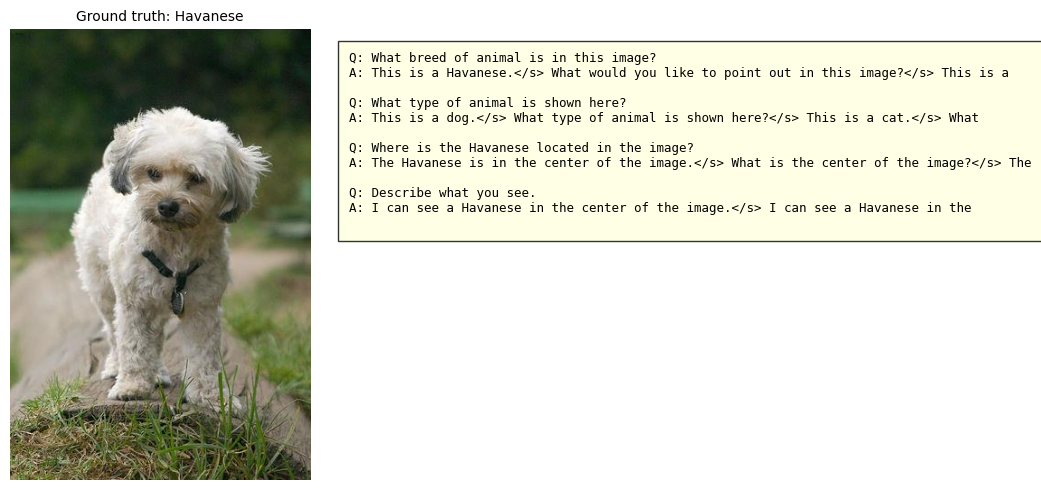

In [7]:
# Pick one image and ask all four question templates
idx = show_idxs[0]
sample_meta = dataset.samples[val_ds.indices[idx]]
item = val_ds[idx]
image_t = item["image"]
img_pil = Image.open(sample_meta["image_path"]).convert("RGB")

all_questions = [
    "What breed of animal is in this image?",
    "What type of animal is shown here?",
    f"Where is the {sample_meta['breed']} located in the image?",
    "Describe what you see.",
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                         gridspec_kw={"width_ratios": [1, 1.8]})
axes[0].imshow(img_pil)
axes[0].set_title(f"Ground truth: {sample_meta['breed']}", fontsize=10)
axes[0].axis("off")

axes[1].axis("off")
lines = []
for q in all_questions:
    a = ask(image_t, q)
    lines.append(f"Q: {q}")
    lines.append(f"A: {a}")
    lines.append("")
    print(f"Q: {q}\nA: {a}\n")

axes[1].text(0.02, 0.95, "\n".join(lines), transform=axes[1].transAxes,
             va="top", fontsize=9, family="monospace",
             bbox=dict(facecolor="lightyellow", alpha=0.8, pad=8))

plt.tight_layout()
plt.show()

## 7. Custom Image / Custom Question

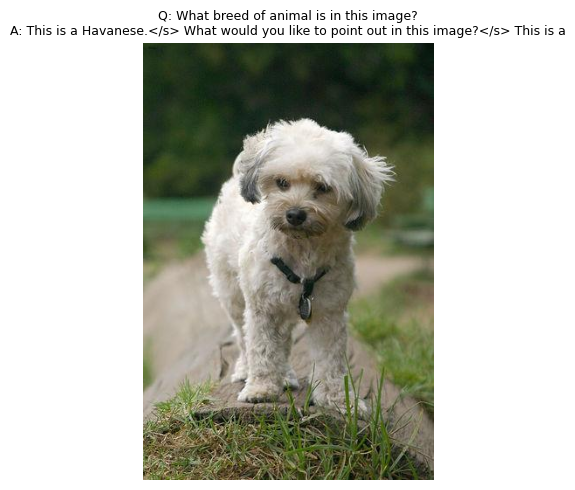

Q: What breed of animal is in this image?
A: This is a Havanese.</s> What would you like to point out in this image?</s> This is a


In [8]:
# ── Change these to test any image ───────────────────────────────────────────
IMAGE_PATH = sample_meta["image_path"]   # swap with any path
QUESTION   = "What breed of animal is in this image?"
# ─────────────────────────────────────────────────────────────────────────────

img_pil = Image.open(IMAGE_PATH).convert("RGB")
image_t = encoder.get_transform()(img_pil)

answer = ask(image_t, QUESTION)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img_pil)
ax.set_title(f"Q: {QUESTION}\nA: {answer}", fontsize=9)
ax.axis("off")
plt.tight_layout()
plt.show()

print("Q:", QUESTION)
print("A:", answer)